# Инжиниринг категориальных признаков

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CS_data = pd.read_csv('./data/Customer_support_data.csv')
CS_data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [76]:
CS_data.describe(include="all")

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


In [77]:
T_data = pd.read_csv('data/titanic.csv')
T_data.describe(exclude=[np.number])

,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,204,889
unique,3,891,2,681,147,3
top,third,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,491,1,577,7,4,644


<Axes: xlabel='channel_name', ylabel='Count'>

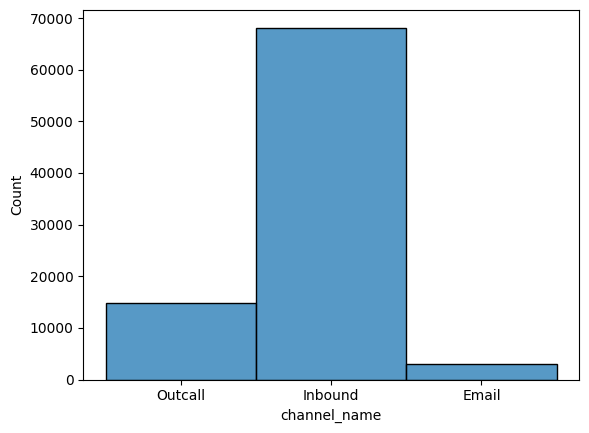

In [78]:
import seaborn as sns
sns.histplot(data=CS_data, x="channel_name")

In [79]:
CS_data.channel_name.value_counts()

channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64

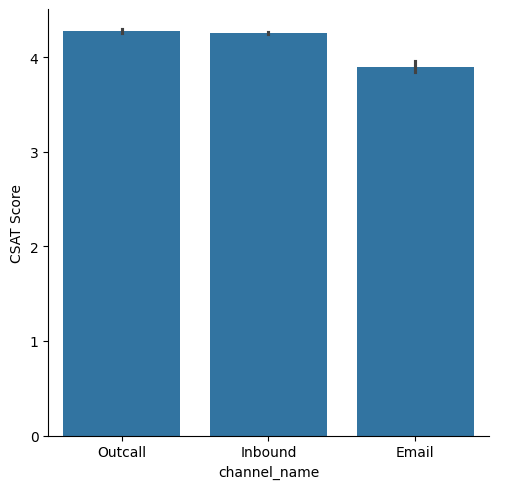

In [80]:
sns.catplot(data=CS_data, x="channel_name", y="CSAT Score", kind="bar")

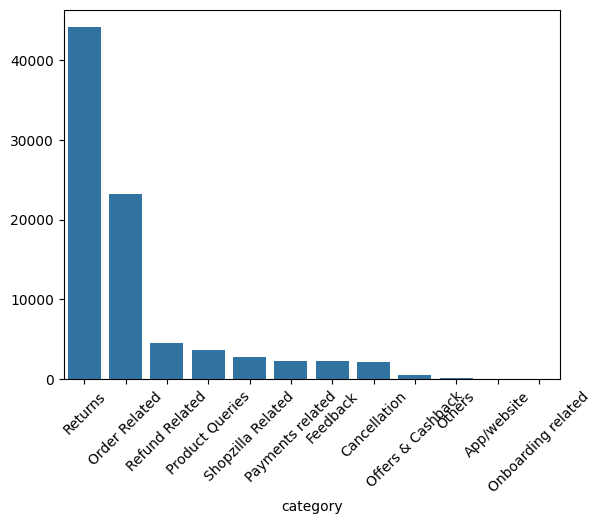

In [81]:
counts = CS_data.category.value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()

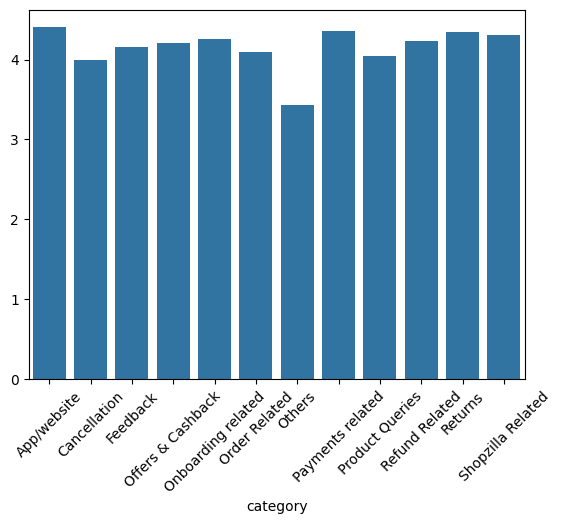

In [82]:
csats = CS_data.groupby("category")["CSAT Score"].mean()
sns.barplot(x=csats.index, y=csats.values)
plt.xticks(rotation=45)
plt.show()

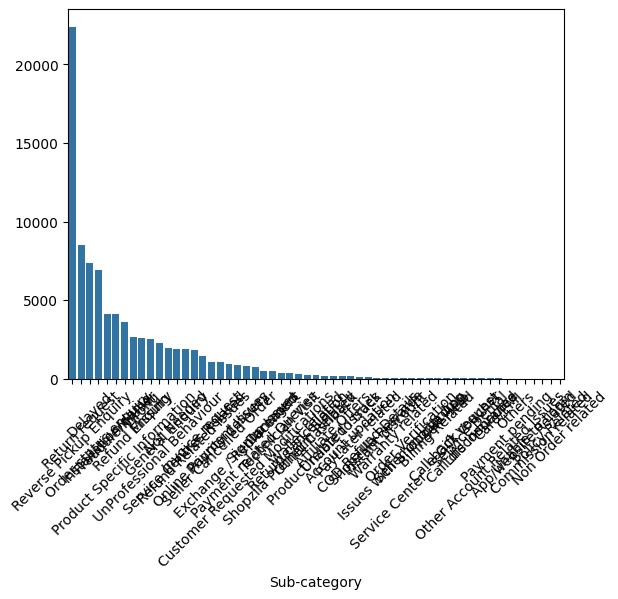

Sub-category
Reverse Pickup Enquiry              22389
Return request                       8523
Delayed                              7388
Order status enquiry                 6922
Installation/demo                    4116
Fraudulent User                      4108
Product Specific Information         3589
Refund Enquiry                       2665
Wrong                                2597
Missing                              2556
UnProfessional Behaviour             2294
General Enquiry                      1945
Not Needed                           1920
Service Centres Related              1875
Refund Related Issues                1800
Invoice request                      1465
Online Payment Issues                1079
Seller Cancelled Order               1059
Priority delivery                     972
Exchange / Replacement                896
Customer Requested Modifications      805
Payment related Queries               743
Signup Issues                         489
Damaged              

In [83]:
counts = CS_data["Sub-category"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()
print(counts)

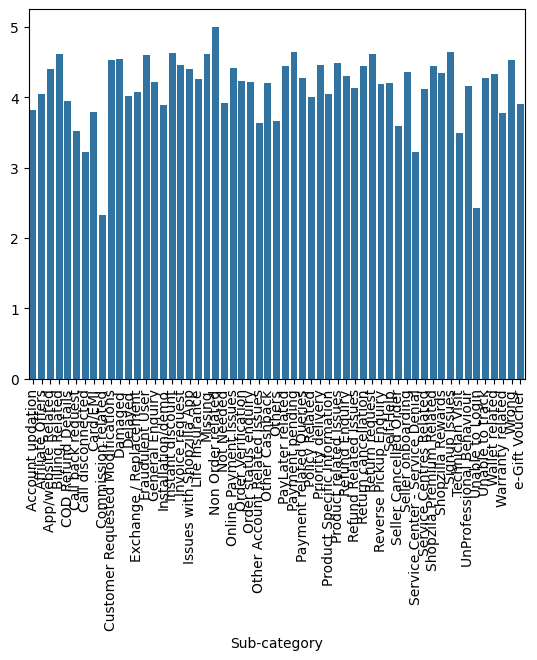

In [84]:
csats = CS_data.groupby("Sub-category")["CSAT Score"].mean()
sns.barplot(x=csats.index, y=csats.values)
plt.xticks(rotation=90)
plt.show()

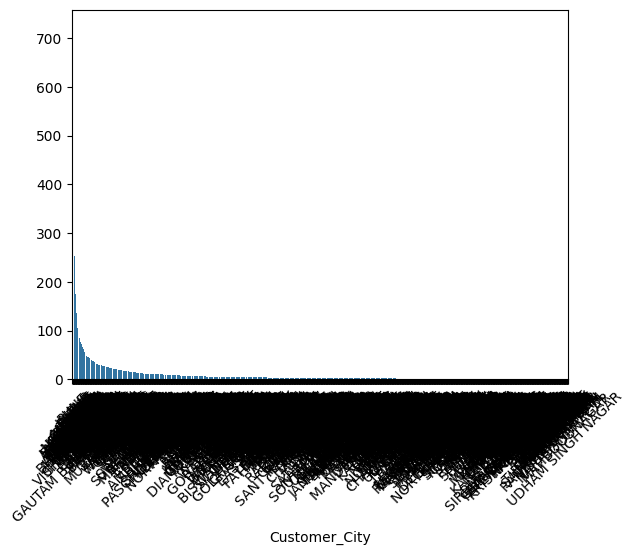

Customer_City
HYDERABAD    722
NEW DELHI    688
PUNE         435
MUMBAI       406
BANGALORE    352
            ... 
SATANA         1
LONGOWAL       1
NAWALGARH      1
VALPOI         1
DORAHA         1
Name: count, Length: 1782, dtype: int64


In [85]:
counts = CS_data["Customer_City"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()
print(counts)

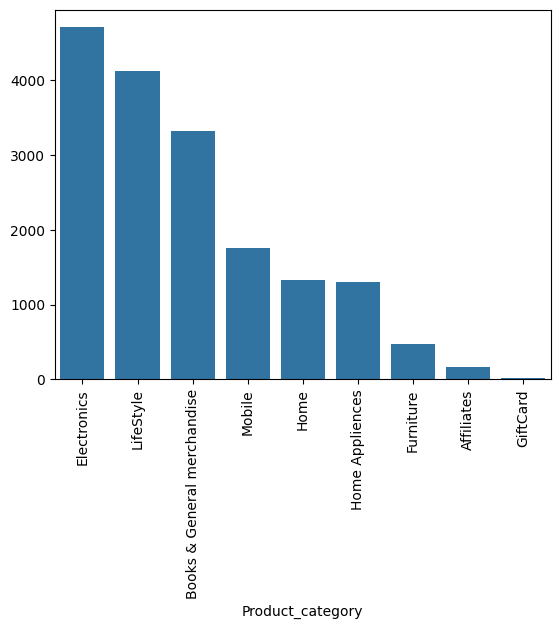

Product_category
Electronics                    4706
LifeStyle                      4118
Books & General merchandise    3323
Mobile                         1758
Home                           1328
Home Appliences                1300
Furniture                       471
Affiliates                      166
GiftCard                         26
Name: count, dtype: int64


In [86]:
counts = CS_data["Product_category"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=90)
plt.show()
print(counts)

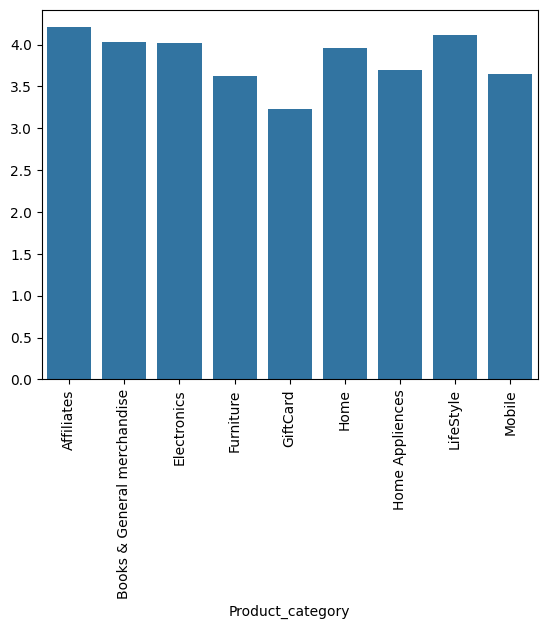

In [87]:
csats = CS_data.groupby("Product_category")["CSAT Score"].mean()
sns.barplot(x=csats.index, y=csats.values)
plt.xticks(rotation=90)
plt.show()

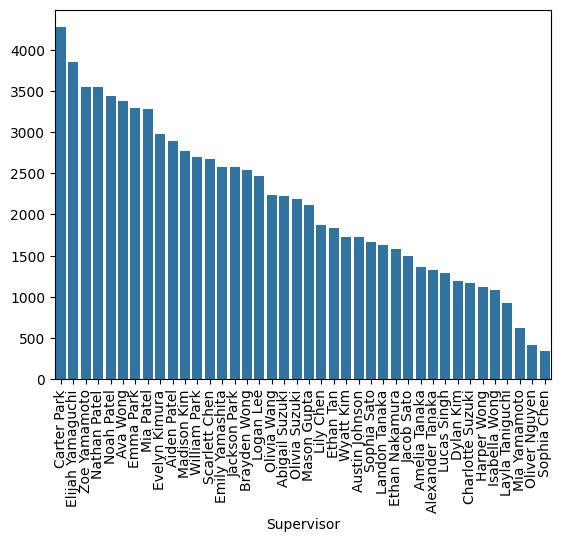

Supervisor
Carter Park         4273
Elijah Yamaguchi    3855
Zoe Yamamoto        3551
Nathan Patel        3549
Noah Patel          3434
Ava Wong            3373
Emma Park           3290
Mia Patel           3279
Evelyn Kimura       2974
Aiden Patel         2892
Madison Kim         2772
William Park        2692
Scarlett Chen       2676
Emily Yamashita     2581
Jackson Park        2571
Brayden Wong        2540
Logan Lee           2466
Olivia Wang         2233
Abigail Suzuki      2222
Olivia Suzuki       2193
Mason Gupta         2109
Lily Chen           1869
Ethan Tan           1831
Wyatt Kim           1727
Austin Johnson      1723
Sophia Sato         1671
Landon Tanaka       1635
Ethan Nakamura      1584
Jacob Sato          1501
Amelia Tanaka       1364
Alexander Tanaka    1320
Lucas Singh         1285
Dylan Kim           1197
Charlotte Suzuki    1172
Harper Wong         1119
Isabella Wong       1081
Layla Taniguchi      924
Mia Yamamoto         625
Oliver Nguyen        417
Sophia Chen   

In [88]:
counts = CS_data["Supervisor"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=90)
plt.show()
print(counts)

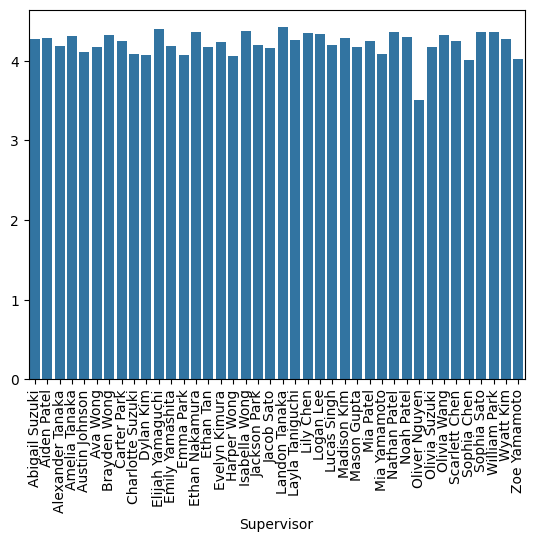

In [89]:
csats = CS_data.groupby("Supervisor")["CSAT Score"].mean()
sns.barplot(x=csats.index, y=csats.values)
plt.xticks(rotation=90)
plt.show()

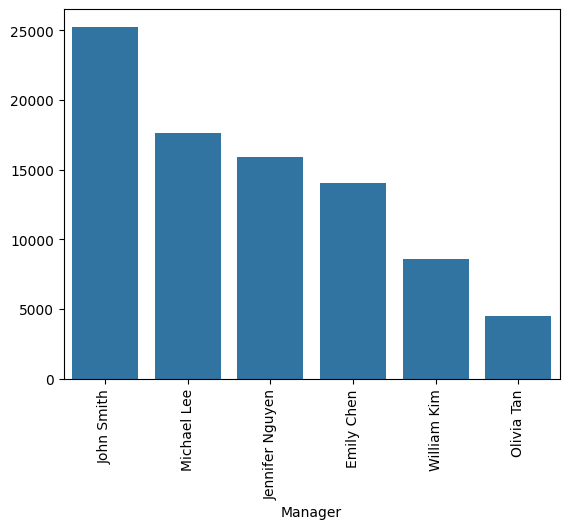

Manager
John Smith         25261
Michael Lee        17600
Jennifer Nguyen    15897
Emily Chen         14062
William Kim         8568
Olivia Tan          4519
Name: count, dtype: int64


In [90]:
counts = CS_data["Manager"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=90)
plt.show()
print(counts)

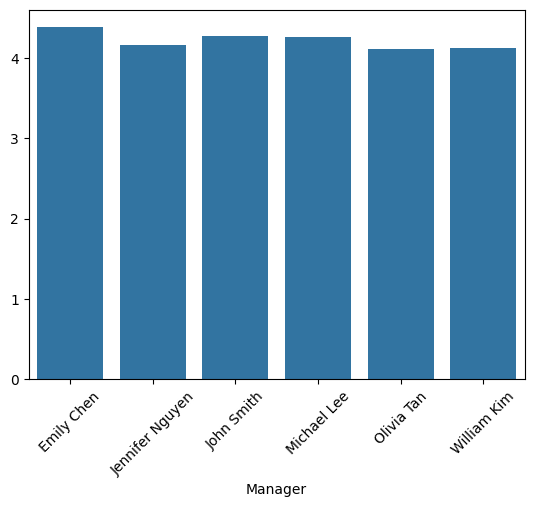

In [91]:
csats = CS_data.groupby("Manager")["CSAT Score"].mean()
sns.barplot(x=csats.index, y=csats.values)
plt.xticks(rotation=45)
plt.show()

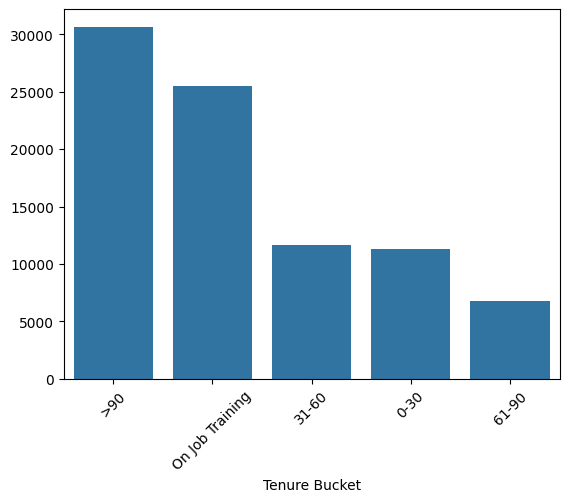

Tenure Bucket
>90                30660
On Job Training    25523
31-60              11665
0-30               11318
61-90               6741
Name: count, dtype: int64


In [92]:
counts = CS_data["Tenure Bucket"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()
print(counts)

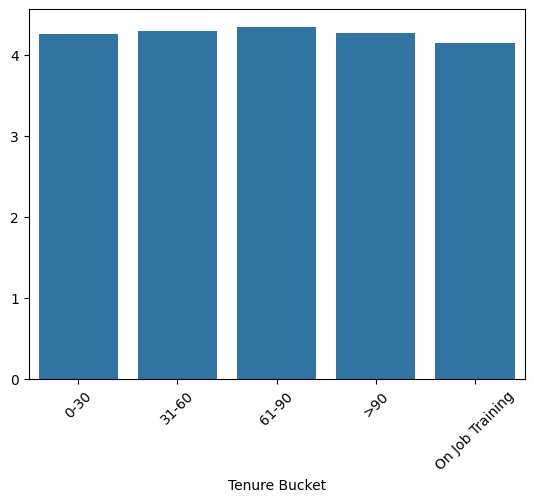

In [93]:
csats = CS_data.groupby("Tenure Bucket")["CSAT Score"].mean()
sns.barplot(x=csats.index, y=csats.values)
plt.xticks(rotation=45)
plt.show()

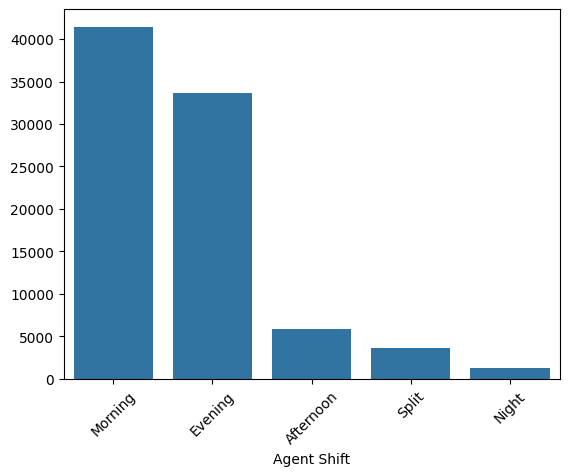

Agent Shift
Morning      41426
Evening      33677
Afternoon     5840
Split         3648
Night         1316
Name: count, dtype: int64


In [94]:
counts = CS_data["Agent Shift"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()
print(counts)

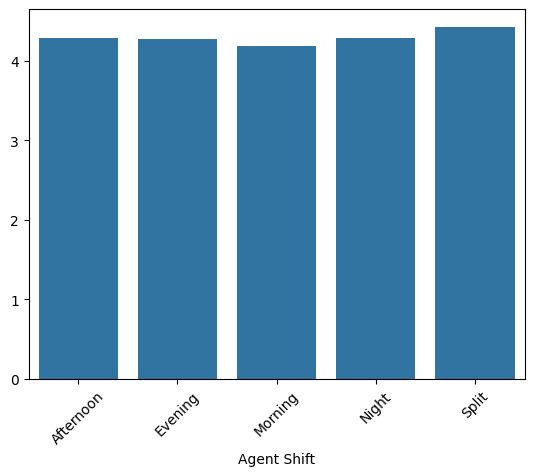

In [95]:
csats = CS_data.groupby("Agent Shift")["CSAT Score"].mean()
sns.barplot(x=csats.index, y=csats.values)
plt.xticks(rotation=45)
plt.show()

In [96]:
CS_data["Customer Remarks New"] = (CS_data["Customer Remarks"].str.len() > 3).astype(int)
print(CS_data["Customer Remarks New"])

0        0
1        0
2        0
3        0
4        0
        ..
85902    0
85903    1
85904    1
85905    0
85906    0
Name: Customer Remarks New, Length: 85907, dtype: int64


In [97]:
CS_data["Is_order"] = (CS_data["Order_id"].isna()).astype(int)
print(CS_data["Is_order"])

0        0
1        0
2        0
3        0
4        0
        ..
85902    0
85903    0
85904    0
85905    0
85906    0
Name: Is_order, Length: 85907, dtype: int64


In [98]:
CS_data.loc[~CS_data["Sub-category"].isin([
    "Reverse Pickup Enquiry", "Return request", "Delayed", "Order status enquiry", 
    "Installation/demo", "Fraudulent User", "Product Specific Information"
    ]), "Sub-category"] = "Other"
CS_data["Sub-category"].value_counts()

Sub-category
Other                           28872
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Name: count, dtype: int64

In [99]:
CS_data.groupby(["Agent_name"]).agg({'Agent_name': 'count'})

,Agent_name
Agent_name,
Aaron Edwards,93
Aaron Romero,59
Abigail Gonzalez,25
Adam Barnett,56
Adam Hammond,60
...,...
Yesenia Bowers,50
Zachary Collins,75
Zachary Ford,62


In [100]:
CS_data['Agent_count'] = CS_data.groupby(["Agent_name"])["Agent_name"].transform('count')
CS_data['Agent_count']

0         42
1         32
2         35
3         48
4        124
        ... 
85902    128
85903     75
85904     31
85905     48
85906     99
Name: Agent_count, Length: 85907, dtype: int64

In [101]:
CS_data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,...,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Customer Remarks New,Is_order,Agent_count
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Other,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,...,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0,0,42
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,...,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0,0,32
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,...,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0,0,35
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,...,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0,0,48
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Other,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,...,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0,0,124


In [102]:
CS_data.groupby(["Supervisor"]).agg({'Agent_name': 'nunique'})

,Agent_name
Supervisor,
Abigail Suzuki,38
Aiden Patel,41
Alexander Tanaka,15
Amelia Tanaka,19
Austin Johnson,29
Ava Wong,70
Brayden Wong,45
Carter Park,64
Charlotte Suzuki,22


In [103]:
CS_data['Sups_no_agents'] = CS_data.groupby(["Supervisor"])["Agent_name"].transform('nunique')
CS_data['Product_category'] = CS_data['Product_category'].fillna('unknown')
CS_data['connected_handling_time'] = CS_data['connected_handling_time'].fillna('0')

In [104]:
from sklearn.preprocessing import LabelEncoder
LE_sex = LabelEncoder()
T_data.Sex = LE_sex.fit_transform(T_data.Sex)
T_data.drop(columns=["Unnamed: 0"], inplace=True)
T_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,third,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,third,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,third,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [105]:
T_data.Pclass.replace({
    'first': 1, 'second': 2, 'third': 3
}, inplace=True)
T_data.head()

C:\Users\vadve\AppData\Local\Temp\ipykernel_34336\3250770238.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  T_data.Pclass.replace({


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,third,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,third,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,third,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [106]:
from sklearn.preprocessing import OneHotEncoder
OH_embarked = OneHotEncoder(sparse_output=False)
OH_embarked.fit_transform(T_data[['Embarked']])

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]], shape=(891, 4))

In [107]:
OH_embarked.get_feature_names_out(['Embarked'])

array(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan'],
      dtype=object)

In [108]:
dummies = pd.DataFrame(OH_embarked.fit_transform(T_data[['Embarked']]),
                       columns=OH_embarked.get_feature_names_out(['Embarked']), 
                       index = T_data.index)

In [109]:
T_dummies = pd.concat([T_data, dummies]).drop(["Embarked"], axis=1)

In [110]:
CS_dropped = CS_data.drop([
    "Unique id",
    "Sub-category",
    "Customer Remarks",
    "Customer_City", 
    "Agent_name", 
    "Supervisor",
    "Order_id",
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date",
    "Item_price",

], axis=1)
CS_dropped.head()

,channel_name,category,Product_category,connected_handling_time,Manager,Tenure Bucket,Agent Shift,CSAT Score,Customer Remarks New,Is_order,Agent_count,Sups_no_agents
0,Outcall,Product Queries,unknown,0,Jennifer Nguyen,On Job Training,Morning,5,0,0,42,41
1,Outcall,Product Queries,unknown,0,Michael Lee,>90,Morning,5,0,0,32,17
2,Inbound,Order Related,unknown,0,William Kim,On Job Training,Evening,5,0,0,35,46
3,Inbound,Returns,unknown,0,John Smith,>90,Evening,5,0,0,48,28
4,Inbound,Cancellation,unknown,0,Michael Lee,0-30,Morning,5,0,0,124,29


In [111]:
CS_dropped.describe()

,CSAT Score,Customer Remarks New,Is_order,Agent_count,Sups_no_agents
count,85907.000000,85907.000000,85907.000000,85907.000000,85907.000000
mean,4.242157,0.319008,0.212230,82.733433,41.358690
std,1.378903,0.466095,0.408889,47.494745,15.862947
min,1.000000,0.000000,0.000000,20.000000,5.000000
25%,4.000000,0.000000,0.000000,53.000000,29.000000
50%,5.000000,0.000000,0.000000,75.000000,41.000000
75%,5.000000,1.000000,0.000000,102.000000,55.000000
max,5.000000,1.000000,1.000000,429.000000,70.000000


In [112]:
CS_dummies = pd.get_dummies(CS_dropped)
CS_dummies.shape

(85907, 258)

## Задания для самостоятельного выполнения

#### 1. Постройте визуализацию распределения признаков и совместного распределения признаков и целевой переменной с помощью тепловых карт. Попробуйте использовать другие инструменты визуализации.

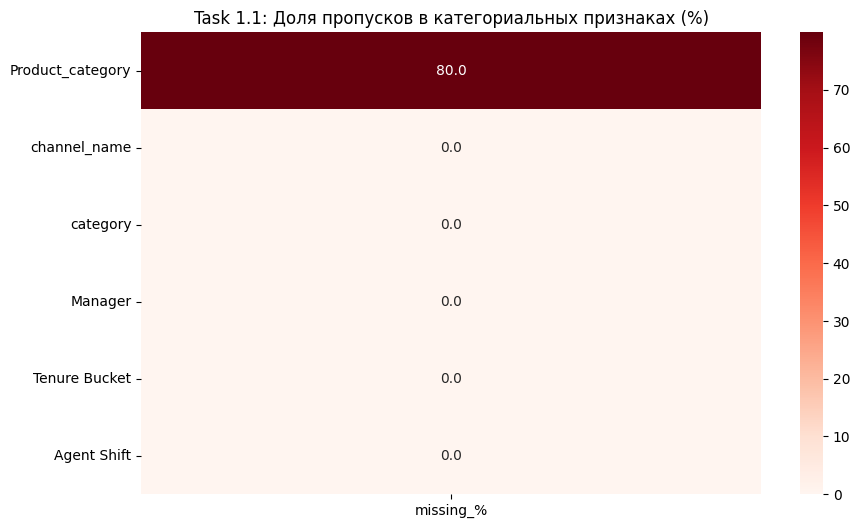

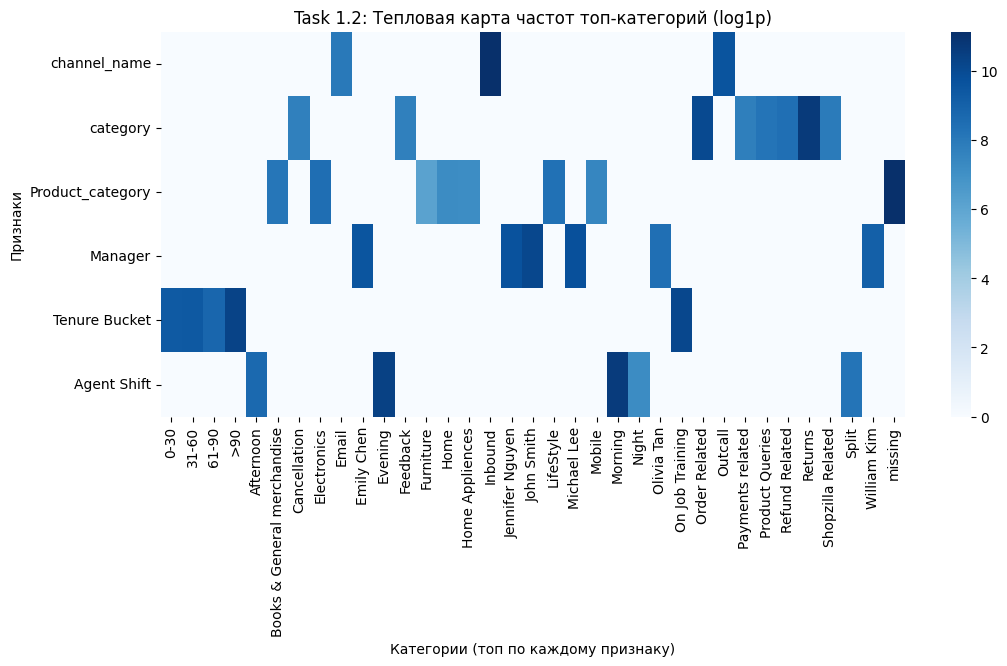

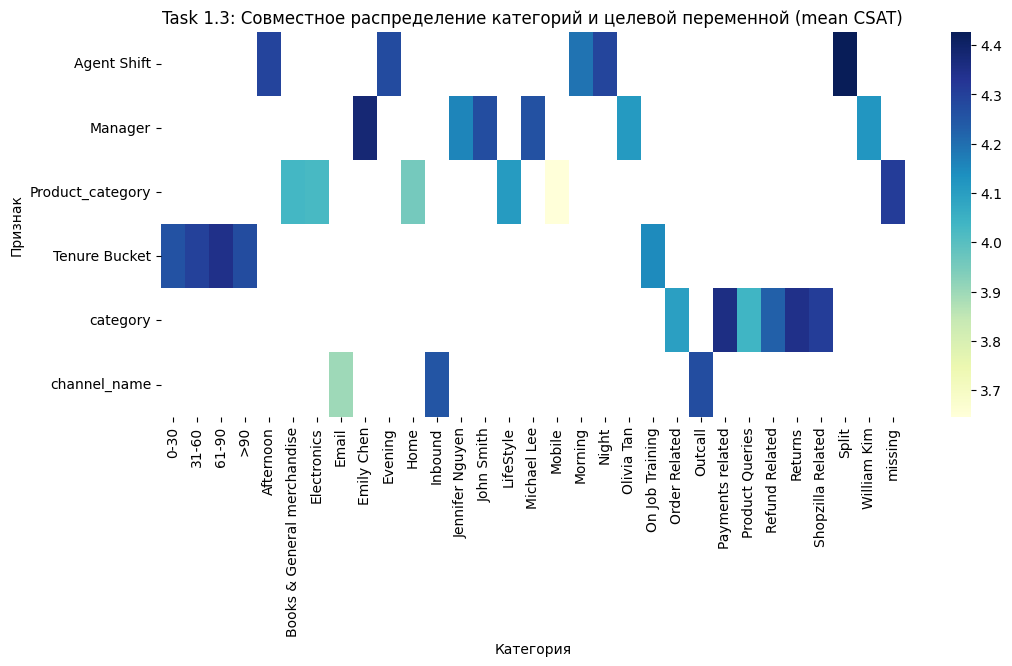

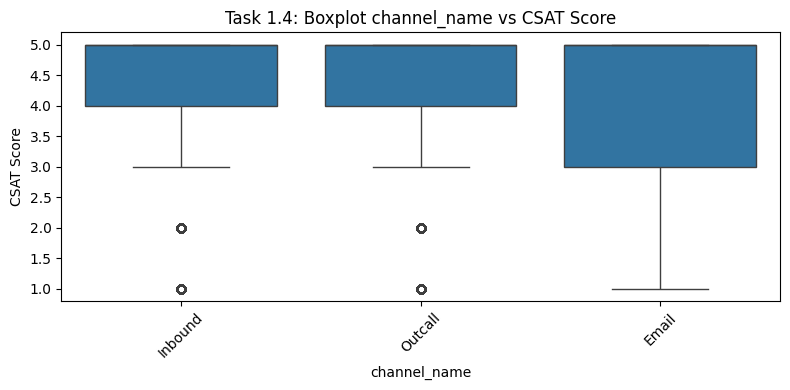

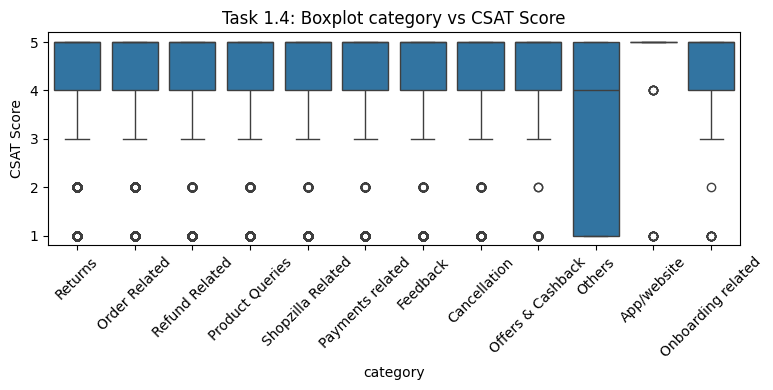

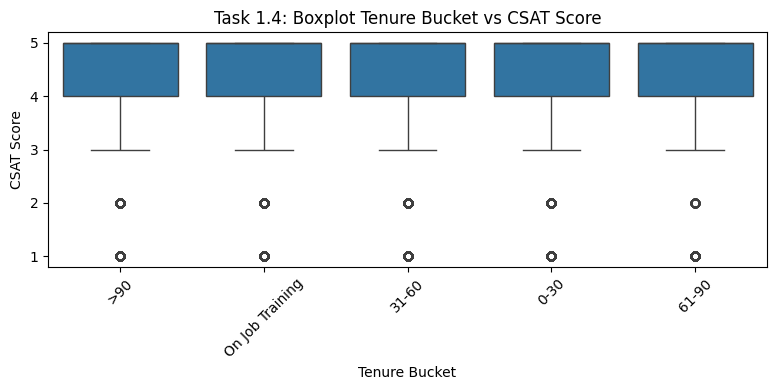

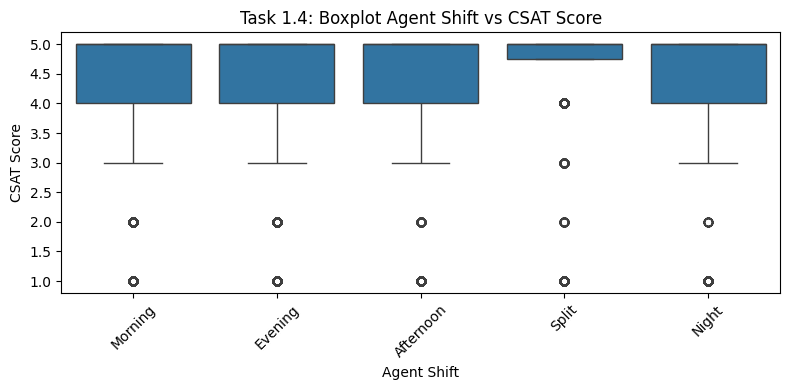

In [119]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cs = pd.read_csv('data/Customer_support_data.csv')
target_col = 'CSAT Score'
all_categorical = cs.select_dtypes(include=['object', 'string']).columns.tolist()
categorical_cols = [col for col in all_categorical if cs[col].nunique(dropna=True) <= 15]

missing_pct = (cs[categorical_cols].isna().mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.heatmap(missing_pct.to_frame('missing_%'), annot=True, cmap='Reds', fmt='.1f')
plt.title('Task 1.1: Доля пропусков в категориальных признаках (%)')
plt.show()

top_n = 8
top_categories = {}
for col in categorical_cols:
    top_categories[col] = cs[col].fillna('missing').value_counts().head(top_n)

frequency_table = pd.DataFrame(top_categories).fillna(0).T
plt.figure(figsize=(12, max(5, len(frequency_table) * 0.5)))
sns.heatmap(np.log1p(frequency_table), cmap='Blues')
plt.title('Task 1.2: Тепловая карта частот топ-категорий (log1p)')
plt.xlabel('Категории (топ по каждому признаку)')
plt.ylabel('Признаки')
plt.show()

mean_target_table = []
for col in categorical_cols:
    top_vals = cs[col].fillna('missing').value_counts().head(6).index
    tmp = cs.copy()
    tmp[col] = tmp[col].fillna('missing')
    tmp = tmp[tmp[col].isin(top_vals)]
    pivot = tmp.groupby(col)[target_col].mean()
    for category_name, mean_value in pivot.items():
        mean_target_table.append({'feature': col, 'category': category_name, 'mean_csat': mean_value})

mean_target_df = pd.DataFrame(mean_target_table)
mean_target_pivot = mean_target_df.pivot_table(index='feature', columns='category', values='mean_csat')
plt.figure(figsize=(12, max(5, len(mean_target_pivot) * 0.5)))
sns.heatmap(mean_target_pivot, annot=False, cmap='YlGnBu')
plt.title('Task 1.3: Совместное распределение категорий и целевой переменной (mean CSAT)')
plt.xlabel('Категория')
plt.ylabel('Признак')
plt.show()

catplot_features = ['channel_name', 'category', 'Tenure Bucket', 'Agent Shift']
for col in catplot_features:
    if col in cs.columns:
        plt.figure(figsize=(8, 4))
        order = cs[col].fillna('missing').value_counts().index
        sns.boxplot(data=cs, x=col, y=target_col, order=order)
        plt.xticks(rotation=45)
        plt.title(f'Task 1.4: Boxplot {col} vs {target_col}')
        plt.tight_layout()
        plt.show()


# Для тепловых карт использованы категориальные признаки с умеренной кардинальностью (до 15 значений)
# Построены карты частот и карты среднего значения целевой переменной по категориям
# Добавлены boxplot-графики как альтернативный инструмент визуализации

#### 2. Постройте на получившимся датасете Customer support модель дерева решений и проанализируйте важность признаков. Сделайте вывод об адекватности наших предположений.

MAE: 1.0202
R2 : 0.0306


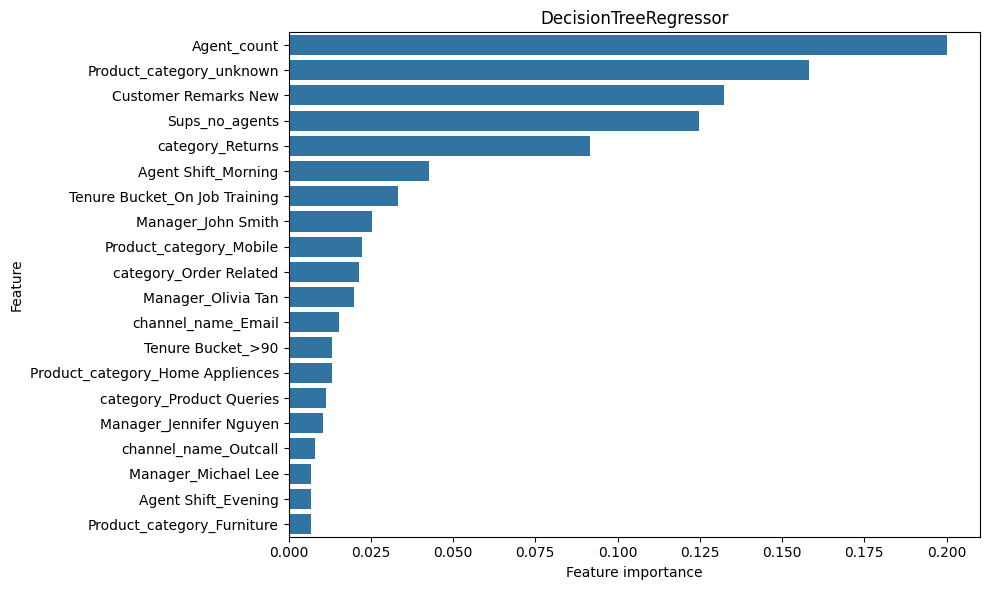

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

cs = pd.read_csv('data/Customer_support_data.csv')

cs['Customer Remarks New'] = (cs['Customer Remarks'].str.len().fillna(0) > 3).astype(int)
cs['Is_order'] = (~cs['Order_id'].isna()).astype(int)
cs['Agent_count'] = cs.groupby('Agent_name')['Agent_name'].transform('count')
cs['Sups_no_agents'] = cs.groupby('Supervisor')['Agent_name'].transform('nunique')
cs['Product_category'] = cs['Product_category'].fillna('unknown')
cs['connected_handling_time'] = pd.to_numeric(cs['connected_handling_time'], errors='coerce').fillna(0)

drop_cols = [
    'Unique id', 'Sub-category', 'Customer Remarks', 'Customer_City', 'Agent_name',
    'Supervisor', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded',
    'Survey_response_Date', 'Item_price'
 ]
cs_model = cs.drop(columns=drop_cols).copy()

y = cs_model['CSAT Score']
X = cs_model.drop(columns=['CSAT Score'])
X_enc = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42
 )

tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=40, random_state=42)
tree.fit(X_train, y_train)
pred = tree.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f'MAE: {mae:.4f}')
print(f'R2 : {r2:.4f}')

imp = pd.Series(tree.feature_importances_, index=X_enc.columns).sort_values(ascending=False)
top_imp = imp.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_imp.values, y=top_imp.index)
plt.title('DecisionTreeRegressor')
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Модель дерева решений построена на подготовленном Customer Support датасете
# Важности признаков рассчитаны и визуализированы
# Полученные важности позволяют проверить адекватность гипотез о значимости признаков

#### 3. Разбейте датасет на тестовую и обучающую выборки и преобразуйте обе подвыборки. Тестовую нужно преобразовывать точно также, как и обучающую (с теми же параметрами).

In [122]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cs = pd.read_csv('./data/Customer_support_data.csv')

cs['Customer Remarks New'] = (cs['Customer Remarks'].str.len().fillna(0) > 3).astype(int)
cs['Is_order'] = (~cs['Order_id'].isna()).astype(int)
cs['Agent_count'] = cs.groupby('Agent_name')['Agent_name'].transform('count')
cs['Sups_no_agents'] = cs.groupby('Supervisor')['Agent_name'].transform('nunique')

drop_cols = [
    'Unique id', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
    'issue_responded', 'Survey_response_Date', 'Agent_name', 'Supervisor'
 ]
data = cs.drop(columns=drop_cols).copy()

y = data['CSAT Score']
X = data.drop(columns=['CSAT Score'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'string']).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

num_features = num_cols
cat_features = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols).tolist()
all_features = num_features + cat_features

print(f'Размер train до преобразования: {X_train.shape}')
print(f'Размер test до преобразования : {X_test.shape}')
print(f'Размер train после преобразования: {X_train_transformed.shape}')
print(f'Размер test после преобразования : {X_test_transformed.shape}')
print(f'Общее число признаков после преобразования: {len(all_features)}')

Размер train до преобразования: (68725, 14)
Размер test до преобразования : (17182, 14)
Размер train после преобразования: (68725, 1760)
Размер test после преобразования : (17182, 1760)
Общее число признаков после преобразования: 1760


#### 4. Проведите полный анализ на датасете Титаник, включая все необходимые визуализации и выводы.

Task 4: Titanic shape: (891, 13)
Task 4: Missing values ratio (%):
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Unnamed: 0      0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
dtype: float64


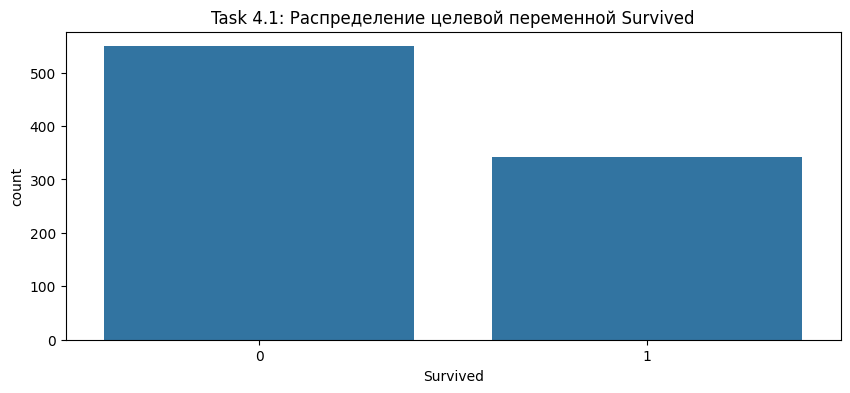

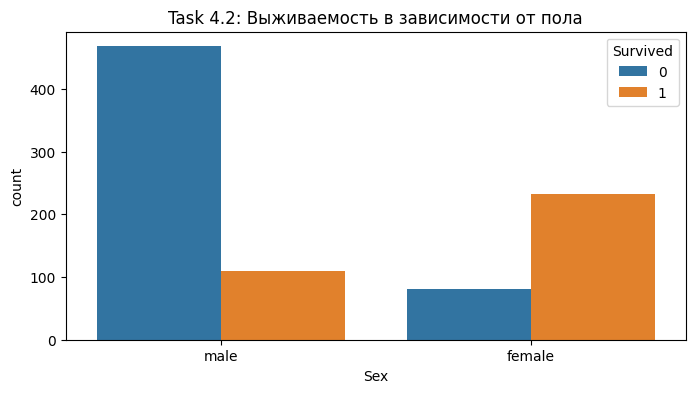

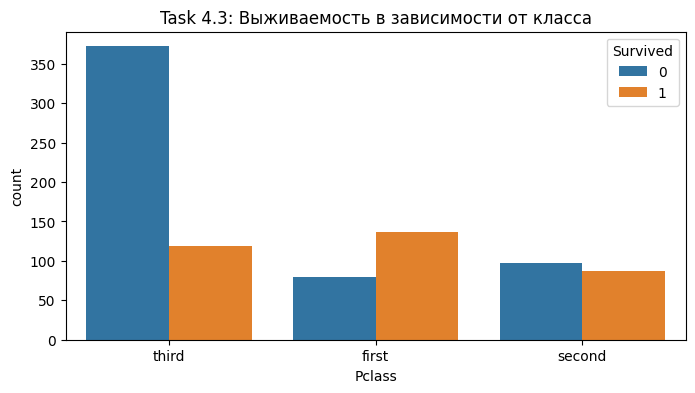

Task 4 metrics:
LogReg Accuracy: 0.7989
LogReg ROC-AUC : 0.8410
RF     Accuracy: 0.8212
RF     ROC-AUC : 0.8385

Task 4 classification report (RandomForest):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



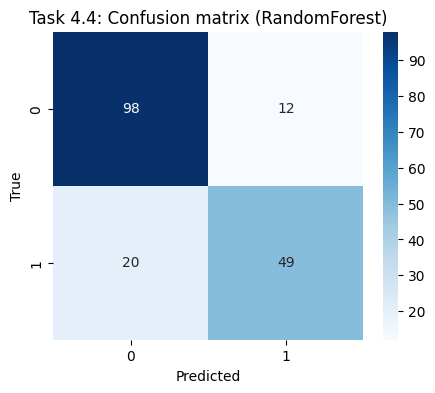

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

titanic = pd.read_csv('./data/titanic.csv')
print('Task 4: Titanic shape:', titanic.shape)
print('Task 4: Missing values ratio (%):')
print((titanic.isna().mean() * 100).sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 4))
sns.countplot(data=titanic, x='Survived')
plt.title('Task 4.1: Распределение целевой переменной Survived')
plt.show()

if 'Sex' in titanic.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=titanic, x='Sex', hue='Survived')
    plt.title('Task 4.2: Выживаемость в зависимости от пола')
    plt.show()

if 'Pclass' in titanic.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=titanic, x='Pclass', hue='Survived')
    plt.title('Task 4.3: Выживаемость в зависимости от класса')
    plt.show()

target = 'Survived'
drop_high_card = [col for col in ['Name', 'Ticket', 'Cabin', 'Unnamed: 0'] if col in titanic.columns]
data = titanic.drop(columns=drop_high_card).copy()

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'string']).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

logreg = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_lr = logreg.predict(X_test)
pred_rf = rf.predict(X_test)
proba_lr = logreg.predict_proba(X_test)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]

print('Task 4 metrics:')
print(f'LogReg Accuracy: {accuracy_score(y_test, pred_lr):.4f}')
print(f'LogReg ROC-AUC : {roc_auc_score(y_test, proba_lr):.4f}')
print(f'RF     Accuracy: {accuracy_score(y_test, pred_rf):.4f}')
print(f'RF     ROC-AUC : {roc_auc_score(y_test, proba_rf):.4f}')

print('\nTask 4 classification report (RandomForest):')
print(classification_report(y_test, pred_rf))

cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Task 4.4: Confusion matrix (RandomForest)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### 5. Проверьте целесообразность каждого необязательного преобразования данных путем проверки, увеличивает ли данное преобразование точность модели. Проверьте на простом виде модели (линейная регрессия, дерево решений или случайный лес). Поэкспериментируйте с различными вариантами преобразований.

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

cs = pd.read_csv('./data/Customer_support_data.csv')

def prepare_variant(df, use_grouping=False, use_engineering=False):
    out = df.copy()
    if use_grouping and 'Sub-category' in out.columns:
        top_sub = out['Sub-category'].value_counts().head(7).index
        out.loc[~out['Sub-category'].isin(top_sub), 'Sub-category'] = 'Other'
    if use_engineering:
        out['Customer Remarks New'] = (out['Customer Remarks'].str.len().fillna(0) > 3).astype(int)
        out['Is_order'] = (~out['Order_id'].isna()).astype(int)
        out['Agent_count'] = out.groupby('Agent_name')['Agent_name'].transform('count')
        out['Sups_no_agents'] = out.groupby('Supervisor')['Agent_name'].transform('nunique')

    drop_cols = [col for col in [
        'Unique id', 'order_date_time', 'Issue_reported at', 'issue_responded',
        'Survey_response_Date', 'Item_price'
    ] if col in out.columns]
    out = out.drop(columns=drop_cols)
    return out

variants = {
    'baseline': dict(use_grouping=False, use_engineering=False),
    'grouping_only': dict(use_grouping=True, use_engineering=False),
    'engineering_only': dict(use_grouping=False, use_engineering=True),
    'grouping_plus_engineering': dict(use_grouping=True, use_engineering=True),
}

rows = []
for name, cfg in variants.items():
    data = prepare_variant(cs, **cfg)
    data['connected_handling_time'] = pd.to_numeric(data['connected_handling_time'], errors='coerce')
    y = data['CSAT Score']
    X = data.drop(columns=['CSAT Score'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
    num_cols = X_train.select_dtypes(exclude=['object', 'string']).columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols),
    ])

    model = Pipeline([
        ('prep', preprocessor),
        ('tree', DecisionTreeRegressor(max_depth=10, min_samples_leaf=40, random_state=42))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rows.append({
        'variant': name,
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred)
    })

results = pd.DataFrame(rows).sort_values('R2', ascending=False)
display(results)

best = results.iloc[0]
print(f"Лучший вариант: {best['variant']} | R2={best['R2']:.4f}, MAE={best['MAE']:.4f}")

# целесообразность преобразований подтверждается сравнением метрик на одинаковой модели

,variant,MAE,R2
0,baseline,1.010027,0.051852
2,engineering_only,1.009496,0.051338
3,grouping_plus_engineering,1.009550,0.050821
1,grouping_only,1.011333,0.050200


Лучший вариант: baseline | R2=0.0519, MAE=1.0100


#### 6. Создайте воспроизводимый код обработки данного датасета.

In [125]:
from dataclasses import dataclass
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

@dataclass
class CustomerSupportPreprocessor:
    top_sub_n: int = 7
    target_col: str = 'CSAT Score'
    fitted: bool = False

    def fit(self, df: pd.DataFrame):
        data = df.copy()
        self.top_sub_categories_ = data['Sub-category'].value_counts().head(self.top_sub_n).index.tolist()
        self.columns_to_drop_ = [
            'Unique id', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
            'issue_responded', 'Survey_response_Date', 'Customer_City', 'Agent_name', 'Supervisor',
            'Item_price'
        ]
        data = self._feature_engineering(data)
        data = data.drop(columns=[c for c in self.columns_to_drop_ if c in data.columns])

        X = data.drop(columns=[self.target_col]) if self.target_col in data.columns else data
        self.cat_cols_ = X.select_dtypes(include=['object', 'string']).columns.tolist()
        self.num_cols_ = X.select_dtypes(exclude=['object', 'string']).columns.tolist()

        self.pipeline_ = ColumnTransformer([
            ('num', SimpleImputer(strategy='median'), self.num_cols_),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore'))
            ]), self.cat_cols_),
        ])

        self.pipeline_.fit(X)
        self.fitted = True
        return self

    def transform(self, df: pd.DataFrame):
        if not self.fitted:
            raise RuntimeError('Preprocessor is not fitted. Call fit() first.')

        data = df.copy()
        data = self._feature_engineering(data)
        data = data.drop(columns=[c for c in self.columns_to_drop_ if c in data.columns])

        if self.target_col in data.columns:
            y = data[self.target_col]
            X = data.drop(columns=[self.target_col])
        else:
            y = None
            X = data

        X_t = self.pipeline_.transform(X)
        return X_t, y

    def fit_transform(self, df: pd.DataFrame):
        self.fit(df)
        return self.transform(df)

    def _feature_engineering(self, data: pd.DataFrame):
        data['Sub-category'] = data['Sub-category'].where(
            data['Sub-category'].isin(self.top_sub_categories_), 'Other'
        )
        data['Customer Remarks New'] = (data['Customer Remarks'].str.len().fillna(0) > 3).astype(int)
        data['Is_order'] = (~data['Order_id'].isna()).astype(int)
        data['Agent_count'] = data.groupby('Agent_name')['Agent_name'].transform('count')
        data['Sups_no_agents'] = data.groupby('Supervisor')['Agent_name'].transform('nunique')
        data['connected_handling_time'] = pd.to_numeric(data['connected_handling_time'], errors='coerce')
        data['Product_category'] = data['Product_category'].fillna('unknown')
        return data

cs = pd.read_csv('data/Customer_support_data.csv')
prep = CustomerSupportPreprocessor(top_sub_n=7)
X_processed, y_processed = prep.fit_transform(cs)
print(f'X_processed shape: {X_processed.shape}')
print(f'y_processed shape: {y_processed.shape}')

# препроцессор можно применять повторно к новым данным теми же параметрами: prep.transform(new_df)

X_processed shape: (85907, 54)
y_processed shape: (85907,)
